# Debugging Distillation Issue

Let me debug the tensor shape mismatch in the distillation process.

In [1]:
# Debug the tensor shape mismatch issue
import torch
import torch.nn as nn
import torch.nn.functional as F

# Test the SimpleUNet with the exact configuration that's failing
class SimpleUNetDebug(nn.Module):
    """Debug version of SimpleUNet to identify shape issues."""
    
    def __init__(self, input_channels=8, num_classes=4, base_filters=16, 
                 depths=[3, 3, 3], channel_multipliers=[1, 2, 3, 4]):
        super(SimpleUNetDebug, self).__init__()
        
        self.input_channels = input_channels
        self.num_classes = num_classes
        self.base_filters = base_filters
        self.depths = depths
        
        # Calculate channel dimensions for each level
        self.channels = [base_filters * mult for mult in channel_multipliers]
        print(f"Channel progression: {self.channels}")
        
        # Simple encoder blocks (just conv + pool for debugging)
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        
        # First encoder block
        self.encoders.append(nn.Conv2d(input_channels, self.channels[0], 3, padding=1))
        
        # Remaining encoder blocks with pooling
        for i in range(len(depths)):
            if i < len(depths) - 1:
                self.pools.append(nn.MaxPool2d(2))
                self.encoders.append(nn.Conv2d(self.channels[i], self.channels[i + 1], 3, padding=1))
        
        # Final pooling before bottleneck
        self.pools.append(nn.MaxPool2d(2))
        
        # Bottleneck
        bottleneck_in = self.channels[-2] if len(self.channels) > 1 else self.channels[0]
        bottleneck_out = self.channels[-1]
        self.bottleneck = nn.Conv2d(bottleneck_in, bottleneck_out, 3, padding=1)
        
        # Decoder (simplified)
        self.upsamplers = nn.ModuleList()
        self.decoders = nn.ModuleList()
        
        # Create decoder blocks
        for i in range(len(depths)):
            # Upsampler
            up_in = self.channels[len(depths) - i]
            up_out = self.channels[len(depths) - i - 1]
            self.upsamplers.append(nn.ConvTranspose2d(up_in, up_out, 2, stride=2))
            
            # Decoder block (simplified - just one conv)
            dec_in = up_out * 2  # Concatenated with skip connection
            dec_out = up_out
            self.decoders.append(nn.Conv2d(dec_in, dec_out, 3, padding=1))
        
        # Final classifier
        self.final_conv = nn.Conv2d(self.channels[0], num_classes, 1)

    def forward(self, x):
        print(f"Input shape: {x.shape}")
        
        # Store encoder outputs for skip connections
        encoder_outputs = []
        
        # Encoder path
        current = x
        for i in range(len(self.depths)):
            current = self.encoders[i](current)
            print(f"After encoder {i}: {current.shape}")
            encoder_outputs.append(current)
            if i < len(self.depths) - 1:
                current = self.pools[i](current)
                print(f"After pool {i}: {current.shape}")
        
        # Final pooling and bottleneck
        current = self.pools[-1](current)
        print(f"After final pool: {current.shape}")
        current = self.bottleneck(current)
        print(f"After bottleneck: {current.shape}")
        
        # Decoder path
        for i in range(len(self.depths)):
            print(f"\n--- Decoder stage {i} ---")
            print(f"Before upsampling: {current.shape}")
            current = self.upsamplers[i](current)
            print(f"After upsampling: {current.shape}")
            
            # Skip connection
            skip_idx = len(self.depths) - 1 - i
            skip = encoder_outputs[skip_idx]
            print(f"Skip connection shape: {skip.shape}")
            
            # Resize if needed
            if current.shape[2:] != skip.shape[2:]:
                print(f"Resizing upsampled from {current.shape[2:]} to {skip.shape[2:]}")
                current = F.interpolate(current, size=skip.shape[2:], mode='bilinear', align_corners=False)
                print(f"After resize: {current.shape}")
            
            current = torch.cat([current, skip], dim=1)
            print(f"After concatenation: {current.shape}")
            
            current = self.decoders[i](current)
            print(f"After decoder {i}: {current.shape}")
        
        # Final output
        out = self.final_conv(current)
        print(f"Final output shape: {out.shape}")
        return out

# Test the failing configuration
print("Testing config_0_16f_1234: 16 filters, [1, 2, 3, 4] multipliers")
model = SimpleUNetDebug(
    input_channels=8,
    num_classes=4,
    base_filters=16,
    depths=[3, 3, 3],  # This should be depth=3 repeated
    channel_multipliers=[1, 2, 3, 4]
)

# Test with the expected input size
batch_size = 8
input_tensor = torch.randn(batch_size, 8, 224, 224)
print(f"\n=== Forward Pass ===")

with torch.no_grad():
    try:
        output = model(input_tensor)
        print(f"\n✅ Success! Output shape: {output.shape}")
        print(f"Expected target shape: [{batch_size}, 224, 224]")
        print(f"Match: {output.shape[2:] == (224, 224)}")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        print(f"Error type: {type(e).__name__}")

Testing config_0_16f_1234: 16 filters, [1, 2, 3, 4] multipliers
Channel progression: [16, 32, 48, 64]

=== Forward Pass ===
Input shape: torch.Size([8, 8, 224, 224])
After encoder 0: torch.Size([8, 16, 224, 224])
After pool 0: torch.Size([8, 16, 112, 112])
After encoder 1: torch.Size([8, 32, 112, 112])
After pool 1: torch.Size([8, 32, 56, 56])
After encoder 2: torch.Size([8, 48, 56, 56])
After final pool: torch.Size([8, 48, 28, 28])
After bottleneck: torch.Size([8, 64, 28, 28])

--- Decoder stage 0 ---
Before upsampling: torch.Size([8, 64, 28, 28])
After upsampling: torch.Size([8, 48, 56, 56])
Skip connection shape: torch.Size([8, 48, 56, 56])
After concatenation: torch.Size([8, 96, 56, 56])
After decoder 0: torch.Size([8, 48, 56, 56])

--- Decoder stage 1 ---
Before upsampling: torch.Size([8, 48, 56, 56])
After upsampling: torch.Size([8, 32, 112, 112])
Skip connection shape: torch.Size([8, 32, 112, 112])
After concatenation: torch.Size([8, 64, 112, 112])
After decoder 1: torch.Size([8

In [2]:
# Test the fix for the depth/channel_multipliers mismatch
print("\n=== Testing the fix ===")

# Simulate the corrected logic
model_config = {
    'n_channels': 8,
    'n_classes': 4,
    'base_filters': 16,
    'depth': 3,
    'channel_multipliers': [1, 2, 3, 4]
}

depth = model_config['depth']
channel_multipliers = model_config['channel_multipliers']
depths = [depth] * (len(channel_multipliers) - 1)  # depths for encoder levels

print(f"Model config depth: {depth}")
print(f"Channel multipliers: {channel_multipliers}")
print(f"Calculated depths: {depths}")
print(f"Depths length: {len(depths)}")
print(f"Channel multipliers length: {len(channel_multipliers)}")
print(f"Match: {len(depths) == len(channel_multipliers) - 1}")

# Test all three configurations
configs = [
    {'name': 'config_0_16f_1234', 'base_filters': 16, 'depth': 3, 'channel_multipliers': [1, 2, 3, 4]},
    {'name': 'config_1_16f_1334', 'base_filters': 16, 'depth': 3, 'channel_multipliers': [1, 3, 3, 4]},
    {'name': 'config_2_24f_1223', 'base_filters': 24, 'depth': 3, 'channel_multipliers': [1, 2, 2, 3]}
]

print("\n=== Testing all configurations ===")
for config in configs:
    print(f"\n{config['name']}:")
    depth = config['depth']
    channel_multipliers = config['channel_multipliers']
    depths = [depth] * (len(channel_multipliers) - 1)
    
    print(f"  Base filters: {config['base_filters']}")
    print(f"  Depth: {depth}")
    print(f"  Channel multipliers: {channel_multipliers}")
    print(f"  Calculated depths: {depths}")
    print(f"  Channels: {[config['base_filters'] * mult for mult in channel_multipliers]}")
    print(f"  ✅ Valid: {len(depths) == len(channel_multipliers) - 1}")


=== Testing the fix ===
Model config depth: 3
Channel multipliers: [1, 2, 3, 4]
Calculated depths: [3, 3, 3]
Depths length: 3
Channel multipliers length: 4
Match: True

=== Testing all configurations ===

config_0_16f_1234:
  Base filters: 16
  Depth: 3
  Channel multipliers: [1, 2, 3, 4]
  Calculated depths: [3, 3, 3]
  Channels: [16, 32, 48, 64]
  ✅ Valid: True

config_1_16f_1334:
  Base filters: 16
  Depth: 3
  Channel multipliers: [1, 3, 3, 4]
  Calculated depths: [3, 3, 3]
  Channels: [16, 48, 48, 64]
  ✅ Valid: True

config_2_24f_1223:
  Base filters: 24
  Depth: 3
  Channel multipliers: [1, 2, 2, 3]
  Calculated depths: [3, 3, 3]
  Channels: [24, 48, 48, 72]
  ✅ Valid: True


In [31]:
import torch
import sys
sys.path.append('/home/gdaga/hydranet')
sys.path.append('/home/gdaga/hydranet/phi/phi2FM/downstream')

from phi.phi2FM.downstream.models.phisatnet_downstream import PhiSatNetDownstream
from phisatnet import PhisatNet

# Create a synthetic input to test shapes
batch_size = 2
channels = 8
height = 216
width = 216

# Create synthetic input (what the distillation should receive)
synthetic_input = torch.randn(batch_size, channels, height, width)
print(f"Synthetic input shape: {synthetic_input.shape}")

# Test teacher model 
print("\n=== Testing Teacher Model ===")
teacher = PhiSatNetDownstream(
    pretrained_path=None,  # Don't load weights, just test architecture
    task='segmentation',
    input_dim=8,
    output_dim=3,
    depths=[2, 2, 8, 2],
    dims=[80, 160, 320, 640],
    img_size=216,
    norm_foundation='group',
    norm_downstream='batch',
    freeze_body=False
)

print(f"Teacher expects input: (batch, {teacher.input_dim}, H, W)")
print(f"Teacher first layer (stem) weight shape: {teacher.stem.conv1.weight.shape}")

# Test student model
print("\n=== Testing Student Model ===")
student = PhisatNet(
    n_channels=8,
    n_classes=3,
    base_filters=16,
    depth=3,
    channel_multipliers=[1, 2, 3, 3]
)

print(f"Student expects input: (batch, {student.n_channels}, H, W)")
print(f"Student first layer weight shape: {student.encoders[0][0].dwconv.weight.shape}")

# Test forward pass shapes
try:
    print("\n=== Testing Forward Passes ===")
    with torch.no_grad():
        teacher_out = teacher(synthetic_input)
        print(f"Teacher output shape: {teacher_out.shape}")
        
        student_out = student(synthetic_input)
        print(f"Student output shape: {student_out.shape}")
        
        print("✅ Both models accept the same input shape successfully!")
        
except Exception as e:
    print(f"❌ Error in forward pass: {e}")
    print(f"Error type: {type(e).__name__}")

ModuleNotFoundError: No module named 'pretrain'

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

path = "/home/gdaga/hydranet/experiments/sweep_results_working_20251106_180130.csv"
df = pd.read_csv(path, sep=';')

In [2]:
df = df[df['success'] == True]

In [3]:
def estimate_windows(tile_size: int = 4096, window_size: int = None) -> int:
    """
    Estimate the number of windows of size S that fit in a tile of given size.
    
    Args:
        tile_size (int): Size of the square tile (default: 4096)
        window_size (int): Size of the square window
        
    Returns:
        int: Number of windows that fit in the tile
        
    Raises:
        ValueError: If window_size is None or larger than tile_size
    """
    if window_size is None:
        raise ValueError('window_size must be specified')
    
    if window_size > tile_size:
        raise ValueError(f'window_size ({window_size}) cannot be larger than tile_size ({tile_size})')
    
    windows_per_dimension = tile_size // window_size
    return windows_per_dimension ** 2

In [4]:
time_col = 'inference_actual_time'
df = df[df['success'] == True].copy()
df['patch_size'] = np.sqrt(df['input_dimension'] / 8).astype(int)
df['num_patches'] = (4096 // df['patch_size']) ** 2
df['total_inference_time'] = df['num_patches'] * df['inference_actual_time']
df['time_x_all_windows'] = df.apply(lambda row: row[time_col] * estimate_windows(window_size=row['input_size']), axis=1)

In [15]:
# Check the data structure first
print("Sample channel_multipliers values:")
print(df['channel_multipliers'].head())
print("\nData types:")
print(f"channel_multipliers: {df['channel_multipliers'].dtype}")
print(f"base_filters: {df['base_filters'].dtype}")

Sample channel_multipliers values:
0    1,1,1,1
1    2,2,2,2
2    1,2,2,2
3    1,2,2,3
4    2,2,2,3
Name: channel_multipliers, dtype: object

Data types:
channel_multipliers: object
base_filters: int64


In [5]:
df.columns 

Index(['experiment_id', 'start_time', 'end_time', 'success', 'input_size',
       'base_filters', 'depth', 'channel_multipliers', 'n_channels',
       'n_classes', 'onnx_conversion_time', 'openvino_conversion_time',
       'inference_total_time', 'inference_actual_time', 'total_time',
       'total_parameters', 'model_size_mb', 'input_dimension',
       'output_dimension', 'encoder_params', 'decoder_params',
       'bottleneck_params', 'other_params', 'encoder_percentage',
       'decoder_percentage', 'bottleneck_percentage', 'other_percentage',
       'peak_memory_inference_mb', 'peak_memory_training_mb', 'peak_elements',
       'latent_level_0_channels', 'latent_level_0_height',
       'latent_level_0_width', 'latent_level_0_elements',
       'latent_level_1_channels', 'latent_level_1_height',
       'latent_level_1_width', 'latent_level_1_elements',
       'latent_level_2_channels', 'latent_level_2_height',
       'latent_level_2_width', 'latent_level_2_elements',
       'latent_lev

In [11]:
df_best = df.sort_values('time_x_all_windows').head(100)
df_best

,experiment_id,start_time,end_time,success,input_size,base_filters,depth,channel_multipliers,n_channels,n_classes,onnx_conversion_time,openvino_conversion_time,inference_total_time,inference_actual_time,total_time,total_parameters,model_size_mb,input_dimension,output_dimension,encoder_params,decoder_params,bottleneck_params,other_params,encoder_percentage,decoder_percentage,bottleneck_percentage,other_percentage,peak_memory_inference_mb,peak_memory_training_mb,peak_elements,latent_level_0_channels,latent_level_0_height,latent_level_0_width,latent_level_0_elements,latent_level_1_channels,latent_level_1_height,latent_level_1_width,latent_level_1_elements,latent_level_2_channels,latent_level_2_height,latent_level_2_width,latent_level_2_elements,latent_level_3_channels,latent_level_3_height,latent_level_3_width,latent_level_3_elements,latent_level_4_channels,latent_level_4_height,latent_level_4_width,latent_level_4_elements,skip_0_channels,skip_0_height,skip_0_width,skip_0_elements,skip_1_channels,skip_1_height,skip_1_width,skip_1_elements,skip_2_channels,skip_2_height,skip_2_width,skip_2_elements,skip_3_channels,skip_3_height,skip_3_width,skip_3_elements,errors,patch_size,num_patches,total_inference_time,time_x_all_windows
1375,exp_1762455475_3868_s216_f16_d3_m1_1_1_1,2025-11-06T19:57:55.803029,2025-11-06T19:58:02.937351,True,216,16,3,"1,1,1,1",8,3,0.326332,3.885031,2.911034,0.263319,7.134335,25619,0.097729,373248,139968,9024,13584,2960,51,35.223857,53.023147,11.553925,0.199071,5.205872,10.411743,1364688,16,216,216,746496,16,108,108,186624,16,54,54,46656,16,27,27,11664,NaN,NaN,NaN,NaN,16,216,216,746496,16,108,108,186624,16,54,54,46656,NaN,NaN,NaN,NaN,NaN,216,324,85.315356,85.315356
2200,exp_1762463415_3929_s312_f16_d3_m1_1_1_1,2025-11-06T22:10:15.528232,2025-11-06T22:10:23.135752,True,312,16,3,"1,1,1,1",8,3,0.358581,3.925195,3.307873,0.519375,7.607530,25619,0.097729,778752,292032,9024,13584,2960,51,35.223857,53.023147,11.553925,0.199071,10.861633,21.723267,2847312,16,312,312,1557504,16,156,156,389376,16,78,78,97344,16,39,39,24336,NaN,NaN,NaN,NaN,16,312,312,1557504,16,156,156,389376,16,78,78,97344,NaN,NaN,NaN,NaN,NaN,312,169,87.774375,87.774375
1650,exp_1762458019_1840_s224_f16_d3_m1_1_1_1,2025-11-06T20:40:19.064195,2025-11-06T20:40:26.342534,True,224,16,3,"1,1,1,1",8,3,0.325213,3.947386,2.990087,0.280969,7.278350,25619,0.097729,401408,150528,9024,13584,2960,51,35.223857,53.023147,11.553925,0.199071,5.598633,11.197266,1467648,16,224,224,802816,16,112,112,200704,16,56,56,50176,16,28,28,12544,NaN,NaN,NaN,NaN,16,224,224,802816,16,112,112,200704,16,56,56,50176,NaN,NaN,NaN,NaN,NaN,224,324,91.033956,91.033956
1100,exp_1762453023_7111_s200_f16_d3_m1_1_1_1,2025-11-06T19:17:03.810610,2025-11-06T19:17:10.925030,True,200,16,3,"1,1,1,1",8,3,0.305034,3.903125,2.894260,0.229593,7.114432,25619,0.097729,320000,120000,9024,13584,2960,51,35.223857,53.023147,11.553925,0.199071,4.463196,8.926392,1170000,16,200,200,640000,16,100,100,160000,16,50,50,40000,16,25,25,10000,NaN,NaN,NaN,NaN,16,200,200,640000,16,100,100,160000,16,50,50,40000,NaN,NaN,NaN,NaN,NaN,200,400,91.837200,91.837200
1925,exp_1762460606_6588_s256_f16_d3_m1_1_1_1,2025-11-06T21:23:26.953072,2025-11-06T21:23:34.290044,True,256,16,3,"1,1,1,1",8,3,0.346791,3.937287,3.040336,0.359700,7.336980,25619,0.097729,524288,196608,9024,13584,2960,51,35.223857,53.023147,11.553925,0.199071,7.312500,14.625000,1916928,16,256,256,1048576,16,128,128,262144,16,64,64,65536,16,32,32,16384,NaN,NaN,NaN,NaN,16,256,256,1048576,16,128,128,262144,16,64,64,65536,NaN,NaN,NaN,NaN,NaN,256,256,92.083200,92.083200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,exp_1762453030_6980_s200_f16_d3_m2_2_2_2,2025-11-06T19:17:10.927660,2025-11-06T19:17:18.360760,True,200,16,3,"2,2,2,2",8,3,

In [7]:
# Devo plottare i migliori 100 modellli per latenza:
# Plot a 3 assi
# Asse x: paramters
# Asse y: depth
# Asse z: time_x_all_windows

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate the depth axis as requested: full channel_multipliers list * base_filters
def calculate_depth_axis(row):
    """Calculate depth as the product of channel_multipliers and base_filters"""
    multipliers = row['channel_multipliers'].split(',')
    # Create full list with all multipliers * base_filters
    depth_list = [int(multiplier) * row['base_filters'] for multiplier in multipliers]
    return str(depth_list)

def calculate_depth_axis_numeric(row):
    """Calculate a numeric depth axis for plotting (sum of all multipliers * base_filters)"""
    multipliers = row['channel_multipliers'].split(',')
    # Sum all multipliers * base_filters for numeric plotting
    return sum([int(multiplier) * row['base_filters'] for multiplier in multipliers])

# Add the depth calculation to the dataframe
df['depth_axis'] = df.apply(calculate_depth_axis, axis=1)
df['depth_axis_numeric'] = df.apply(calculate_depth_axis_numeric, axis=1)

# Get the best 100 models by latency (lowest time_x_all_windows)
df_best = df.sort_values('time_x_all_windows').head(100)

print("Sample depth axis values:")
print(df_best[['base_filters', 'channel_multipliers', 'depth_axis', 'depth_axis_numeric']].head())

# Create interactive 3D plot with Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=df_best['total_parameters'],
    y=df_best['depth_axis_numeric'],
    z=df_best['time_x_all_windows'],
    mode='markers',
    marker=dict(
        size=8,
        color=df_best['patch_size'],
        colorscale='Viridis',
        colorbar=dict(title="Patch Size"),
        opacity=0.8
    ),
    text=[f"Base Filters: {bf}<br>"
          f"Multipliers: {cm}<br>"
          f"Depth List: {da}<br>"
          f"Parameters: {tp:,}<br>"
          f"Patch Size: {ps}x{ps}<br>"
          f"Total Time: {tw:.3f}s<br>"
          f"Per-patch: {it:.3f}s"
          for bf, cm, da, tp, ps, tw, it in zip(
              df_best['base_filters'],
              df_best['channel_multipliers'],
              df_best['depth_axis'],
              df_best['total_parameters'],
              df_best['patch_size'],
              df_best['time_x_all_windows'],
              df_best['inference_actual_time']
          )],
    hovertemplate='<b>%{text}</b><extra></extra>'
)])

fig.update_layout(
    title={
        'text': 'Interactive 3D Analysis: Best 100 Models by Total Time<br><sub>Z-axis: time_x_all_windows, Colors: Patch Size - Hover for details</sub>',
        'x': 0.5,
        'xanchor': 'center'
    },
    scene=dict(
        xaxis_title='Total Parameters',
        yaxis_title='Depth Axis (Sum of Multipliers × Base Filters)',
        zaxis_title='Total Time: time_x_all_windows (s)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=900,
    height=700,
    font=dict(size=12)
)

fig.show()

# Show some statistics
print(f"\nBest 100 models statistics:")
print(f"Parameters range: {df_best['total_parameters'].min():,} - {df_best['total_parameters'].max():,}")
print(f"Depth axis numeric range: {df_best['depth_axis_numeric'].min()} - {df_best['depth_axis_numeric'].max()}")
print(f"Total time (time_x_all_windows) range: {df_best['time_x_all_windows'].min():.3f}s - {df_best['time_x_all_windows'].max():.3f}s")
print(f"Patch size range: {df_best['patch_size'].min()} - {df_best['patch_size'].max()}")

Sample depth axis values:
      base_filters channel_multipliers        depth_axis  depth_axis_numeric
1375            16             1,1,1,1  [16, 16, 16, 16]                  64
2200            16             1,1,1,1  [16, 16, 16, 16]                  64
1650            16             1,1,1,1  [16, 16, 16, 16]                  64
1100            16             1,1,1,1  [16, 16, 16, 16]                  64
1925            16             1,1,1,1  [16, 16, 16, 16]                  64



Best 100 models statistics:
Parameters range: 25,619 - 323,427
Depth axis numeric range: 64 - 240
Total time (time_x_all_windows) range: 85.315s - 173.926s
Patch size range: 96 - 312


In [29]:
# Create additional interactive plots to better understand the relationships
from plotly.subplots import make_subplots

# Create a subplot with multiple interactive visualizations
fig_multi = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Parameters vs Total Time', 'Depth vs Total Time', 'Parameters vs Depth', 'Top 10 Models'),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "scatter"}, {"type": "bar"}]]
)

# Plot 1: Parameters vs Total Time (colored by patch size)
fig_multi.add_trace(
    go.Scatter(
        x=df_best['total_parameters'],
        y=df_best['time_x_all_windows'],
        mode='markers',
        marker=dict(
            color=df_best['patch_size'],
            colorscale='Plasma',
            size=8,
            opacity=0.7
        ),
        text=[f"Filters: {bf}, Mult: {cm}<br>Depth: {da}<br>Params: {tp:,}<br>Patch Size: {ps}x{ps}<br>Total Time: {tw:.3f}s"
              for bf, cm, da, tp, ps, tw in zip(
                  df_best['base_filters'],
                  df_best['channel_multipliers'],
                  df_best['depth_axis'],
                  df_best['total_parameters'],
                  df_best['patch_size'],
                  df_best['time_x_all_windows']
              )],
        hovertemplate='<b>%{text}</b><extra></extra>',
        name='Models'
    ),
    row=1, col=1
)

# Plot 2: Depth vs Total Time (colored by patch size)
fig_multi.add_trace(
    go.Scatter(
        x=df_best['depth_axis_numeric'],
        y=df_best['time_x_all_windows'],
        mode='markers',
        marker=dict(
            color=df_best['patch_size'],
            colorscale='Viridis',
            size=8,
            opacity=0.7
        ),
        text=[f"Filters: {bf}, Mult: {cm}<br>Depth: {da}<br>Params: {tp:,}<br>Patch Size: {ps}x{ps}<br>Total Time: {tw:.3f}s"
              for bf, cm, da, tp, ps, tw in zip(
                  df_best['base_filters'],
                  df_best['channel_multipliers'],
                  df_best['depth_axis'],
                  df_best['total_parameters'],
                  df_best['patch_size'],
                  df_best['time_x_all_windows']
              )],
        hovertemplate='<b>%{text}</b><extra></extra>',
        name='Models',
        showlegend=False
    ),
    row=1, col=2
)

# Plot 3: Parameters vs Depth (colored by patch size)
fig_multi.add_trace(
    go.Scatter(
        x=df_best['total_parameters'],
        y=df_best['depth_axis_numeric'],
        mode='markers',
        marker=dict(
            color=df_best['patch_size'],
            colorscale='RdYlBu_r',
            size=8,
            opacity=0.7
        ),
        text=[f"Filters: {bf}, Mult: {cm}<br>Depth: {da}<br>Params: {tp:,}<br>Patch Size: {ps}x{ps}<br>Total Time: {tw:.3f}s"
              for bf, cm, da, tp, ps, tw in zip(
                  df_best['base_filters'],
                  df_best['channel_multipliers'],
                  df_best['depth_axis'],
                  df_best['total_parameters'],
                  df_best['patch_size'],
                  df_best['time_x_all_windows']
              )],
        hovertemplate='<b>%{text}</b><extra></extra>',
        name='Models',
        showlegend=False
    ),
    row=2, col=1
)

# Plot 4: Top 10 models bar chart (colored by patch size)
df_top10 = df_best.head(10)
fig_multi.add_trace(
    go.Bar(
        x=list(range(1, 11)),
        y=df_top10['time_x_all_windows'],
        marker=dict(
            color=df_top10['patch_size'],
            colorscale='Viridis'
        ),
        text=[f"Rank {i+1}<br>Filters: {bf}<br>Mult: {cm}<br>Depth: {da}<br>Patch Size: {ps}x{ps}<br>Total Time: {tw:.3f}s"
              for i, (bf, cm, da, ps, tw) in enumerate(zip(
                  df_top10['base_filters'],
                  df_top10['channel_multipliers'],
                  df_top10['depth_axis'],
                  df_top10['patch_size'],
                  df_top10['time_x_all_windows']
              ))],
        hovertemplate='<b>%{text}</b><extra></extra>',
        name='Top 10',
        showlegend=False
    ),
    row=2, col=2
)

# Update layout
fig_multi.update_xaxes(title_text="Total Parameters", row=1, col=1)
fig_multi.update_yaxes(title_text="Total Time: time_x_all_windows (s)", row=1, col=1)

fig_multi.update_xaxes(title_text="Depth Axis (Sum Mult×Filters)", row=1, col=2)
fig_multi.update_yaxes(title_text="Total Time: time_x_all_windows (s)", row=1, col=2)

fig_multi.update_xaxes(title_text="Total Parameters", row=2, col=1)
fig_multi.update_yaxes(title_text="Depth Axis (Sum Mult×Filters)", row=2, col=1)

fig_multi.update_xaxes(title_text="Model Rank", row=2, col=2)
fig_multi.update_yaxes(title_text="Total Time: time_x_all_windows (s)", row=2, col=2)

fig_multi.update_layout(
    title_text="Interactive Multi-View Analysis: Best 100 Models (Colored by Patch Size)",
    height=800,
    width=1200,
    showlegend=True
)

fig_multi.show()

# Show detailed breakdown of patch size patterns
print("\n" + "="*80)
print("PATCH SIZE ANALYSIS - Impact on Performance")
print("="*80)

# Group by patch size
patch_patterns = df_best.groupby('patch_size').agg({
    'time_x_all_windows': ['count', 'mean', 'min', 'max'],
    'total_parameters': ['mean', 'min', 'max'],
    'depth_axis_numeric': ['mean', 'min', 'max'],
    'base_filters': lambda x: list(x.unique()),
    'channel_multipliers': lambda x: list(x.unique()[:3])  # Show first 3 to avoid clutter
}).round(3)

print(f"\nFound {len(patch_patterns)} unique patch sizes in top 100:")
for patch_size, data in patch_patterns.iterrows():
    count = data[('time_x_all_windows', 'count')]
    mean_time = data[('time_x_all_windows', 'mean')]
    min_time = data[('time_x_all_windows', 'min')]
    max_time = data[('time_x_all_windows', 'max')]
    mean_params = data[('total_parameters', 'mean')]
    mean_depth = data[('depth_axis_numeric', 'mean')]
    
    print(f"\nPatch Size: {patch_size}x{patch_size}")
    print(f"  Count: {count} models")
    print(f"  Total time range: {min_time:.3f}s - {max_time:.3f}s (avg: {mean_time:.3f}s)")
    print(f"  Average parameters: {mean_params:,.0f}")
    print(f"  Average depth sum: {mean_depth:.0f}")
    print(f"  Base filters used: {data[('base_filters', '<lambda>')]}")
    print(f"  Sample multipliers: {data[('channel_multipliers', '<lambda>')]}")

# Show correlation between patch size and performance
patch_correlation = df_best[['patch_size', 'time_x_all_windows']].corr().iloc[0,1]
print(f"\nCorrelation between Patch Size and Total Time: {patch_correlation:.4f}")
print("(Positive correlation means larger patches → longer total time)")


PATCH SIZE ANALYSIS - Impact on Performance

Found 7 unique patch sizes in top 100:

Patch Size: 96x96
  Count: 7 models
  Total time range: 129.829s - 172.736s (avg: 161.015s)
  Average parameters: 104,730
  Average depth sum: 130
  Base filters used: [np.int64(16)]
  Sample multipliers: ['1,1,1,1', '1,2,2,2', '1,2,2,3']

Patch Size: 128x128
  Count: 8 models
  Total time range: 120.204s - 161.028s (avg: 141.348s)
  Average parameters: 98,218
  Average depth sum: 126
  Base filters used: [np.int64(16), np.int64(24)]
  Sample multipliers: ['1,1,1,1', '1,2,2,2', '1,2,2,3']

Patch Size: 200x200
  Count: 17 models
  Total time range: 91.837s - 173.926s (avg: 143.597s)
  Average parameters: 132,177
  Average depth sum: 146
  Base filters used: [np.int64(16), np.int64(24), np.int64(18), np.int64(32)]
  Sample multipliers: ['1,1,1,1', '1,2,2,2', '1,2,2,3']

Patch Size: 216x216
  Count: 18 models
  Total time range: 85.315s - 163.202s (avg: 136.016s)
  Average parameters: 130,806
  Average d

In [26]:
# Create a comprehensive interactive table showing the full multiplier details
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a detailed table of the top 20 models with full multiplier information
df_top20 = df_best.head(20).copy()

# Create an interactive table
fig_table = go.Figure(data=[go.Table(
    columnwidth=[60, 80, 120, 150, 100, 100, 120, 100],
    header=dict(
        values=['<b>Rank</b>', '<b>Base Filters</b>', '<b>Channel Multipliers</b>', 
                '<b>Depth List<br>[mult×filters]</b>', '<b>Parameters</b>', 
                '<b>Patch Size</b>', '<b>Total Time (s)<br>time_x_all_windows</b>', '<b>Per-patch (s)</b>'],
        font=dict(size=12),
        align="center",
        fill_color="paleturquoise"
    ),
    cells=dict(
        values=[
            list(range(1, 21)),  # Rank
            df_top20['base_filters'],  # Base filters
            df_top20['channel_multipliers'],  # Channel multipliers
            df_top20['depth_axis'],  # Full depth list
            [f"{p:,}" for p in df_top20['total_parameters']],  # Parameters (formatted)
            [f"{ps}×{ps}" for ps in df_top20['patch_size']],  # Patch size
            [f"{t:.3f}" for t in df_top20['time_x_all_windows']],  # Total time (time_x_all_windows)
            [f"{t:.3f}" for t in df_top20['inference_actual_time']]  # Per-patch time
        ],
        font=dict(size=11),
        align="center",
        fill_color=[
            ['lightgray' if i % 2 == 0 else 'white' for i in range(20)] for _ in range(8)
        ]
    )
)])

fig_table.update_layout(
    title="Top 20 Models - Detailed Analysis with Full Multiplier Lists (Sorted by time_x_all_windows)",
    height=600,
    font=dict(size=10)
)

fig_table.show()

# Create a summary analysis of the most effective patterns
print("\n" + "="*90)
print("MOST EFFECTIVE DEPTH PATTERNS ANALYSIS (Based on time_x_all_windows)")
print("="*90)

# Find the most common and fastest patterns
pattern_performance = df_best.groupby(['base_filters', 'channel_multipliers']).agg({
    'time_x_all_windows': ['count', 'mean', 'min', 'std'],
    'total_parameters': ['mean'],
    'depth_axis': 'first',
    'depth_axis_numeric': 'first'
}).round(3)

# Sort by mean performance (time_x_all_windows)
pattern_performance = pattern_performance.sort_values(('time_x_all_windows', 'mean'))

print("\nTop 10 Most Effective Base Filter + Channel Multiplier Combinations:")
print("-" * 90)
for i, ((bf, cm), data) in enumerate(pattern_performance.head(10).iterrows()):
    count = data[('time_x_all_windows', 'count')]
    mean_time = data[('time_x_all_windows', 'mean')]
    min_time = data[('time_x_all_windows', 'min')]
    std_time = data[('time_x_all_windows', 'std')]
    mean_params = data[('total_parameters', 'mean')]
    depth_list = data[('depth_axis', 'first')]
    depth_numeric = data[('depth_axis_numeric', 'first')]
    
    print(f"\n{i+1:2d}. Base Filters: {bf:2d}, Channel Multipliers: {cm}")
    print(f"    Depth List: {depth_list}")
    print(f"    Depth Sum: {depth_numeric}")
    print(f"    Models in top 100: {count}")
    print(f"    Average total time: {mean_time:.3f}s ± {std_time:.3f}s")
    print(f"    Best total time: {min_time:.3f}s")
    print(f"    Average parameters: {mean_params:,.0f}")

# Show correlation between depth sum and performance
depth_correlation = df_best[['depth_axis_numeric', 'time_x_all_windows']].corr().iloc[0,1]
print(f"\nCorrelation between Depth Sum and Total Time: {depth_correlation:.4f}")
print("(Negative correlation means lower depth sum → faster total time)")

# Show the distribution of total times
print(f"\nTotal Time (time_x_all_windows) Distribution in Top 100:")
print(f"  Minimum: {df_best['time_x_all_windows'].min():.3f}s")
print(f"  25th percentile: {df_best['time_x_all_windows'].quantile(0.25):.3f}s")
print(f"  Median: {df_best['time_x_all_windows'].median():.3f}s")
print(f"  75th percentile: {df_best['time_x_all_windows'].quantile(0.75):.3f}s")
print(f"  Maximum: {df_best['time_x_all_windows'].max():.3f}s")

# Show depth sum distribution
print(f"\nDepth Sum Distribution in Top 100:")
print(f"  Minimum: {df_best['depth_axis_numeric'].min()}")
print(f"  25th percentile: {df_best['depth_axis_numeric'].quantile(0.25)}")
print(f"  Median: {df_best['depth_axis_numeric'].median()}")
print(f"  75th percentile: {df_best['depth_axis_numeric'].quantile(0.75)}")
print(f"  Maximum: {df_best['depth_axis_numeric'].max()}")
print(f"  Most common: {df_best['depth_axis_numeric'].mode().iloc[0]}")


MOST EFFECTIVE DEPTH PATTERNS ANALYSIS (Based on time_x_all_windows)

Top 10 Most Effective Base Filter + Channel Multiplier Combinations:
------------------------------------------------------------------------------------------

 1. Base Filters: 16, Channel Multipliers: 1,1,1,1
    Depth List: [16, 16, 16, 16]
    Depth Sum: 64
    Models in top 100: 7
    Average total time: 99.725s ± 17.665s
    Best total time: 85.315s
    Average parameters: 25,619

 2. Base Filters: 16, Channel Multipliers: 1,2,2,2
    Depth List: [16, 32, 32, 32]
    Depth Sum: 112
    Models in top 100: 7
    Average total time: 119.573s ± 20.360s
    Best total time: 102.873s
    Average parameters: 74,067

 3. Base Filters: 16, Channel Multipliers: 1,2,2,3
    Depth List: [16, 32, 32, 48]
    Depth Sum: 128
    Models in top 100: 14
    Average total time: 120.519s ± 20.158s
    Best total time: 103.449s
    Average parameters: 92,451

 4. Base Filters: 16, Channel Multipliers: 1,2,3,3
    Depth List: [16,

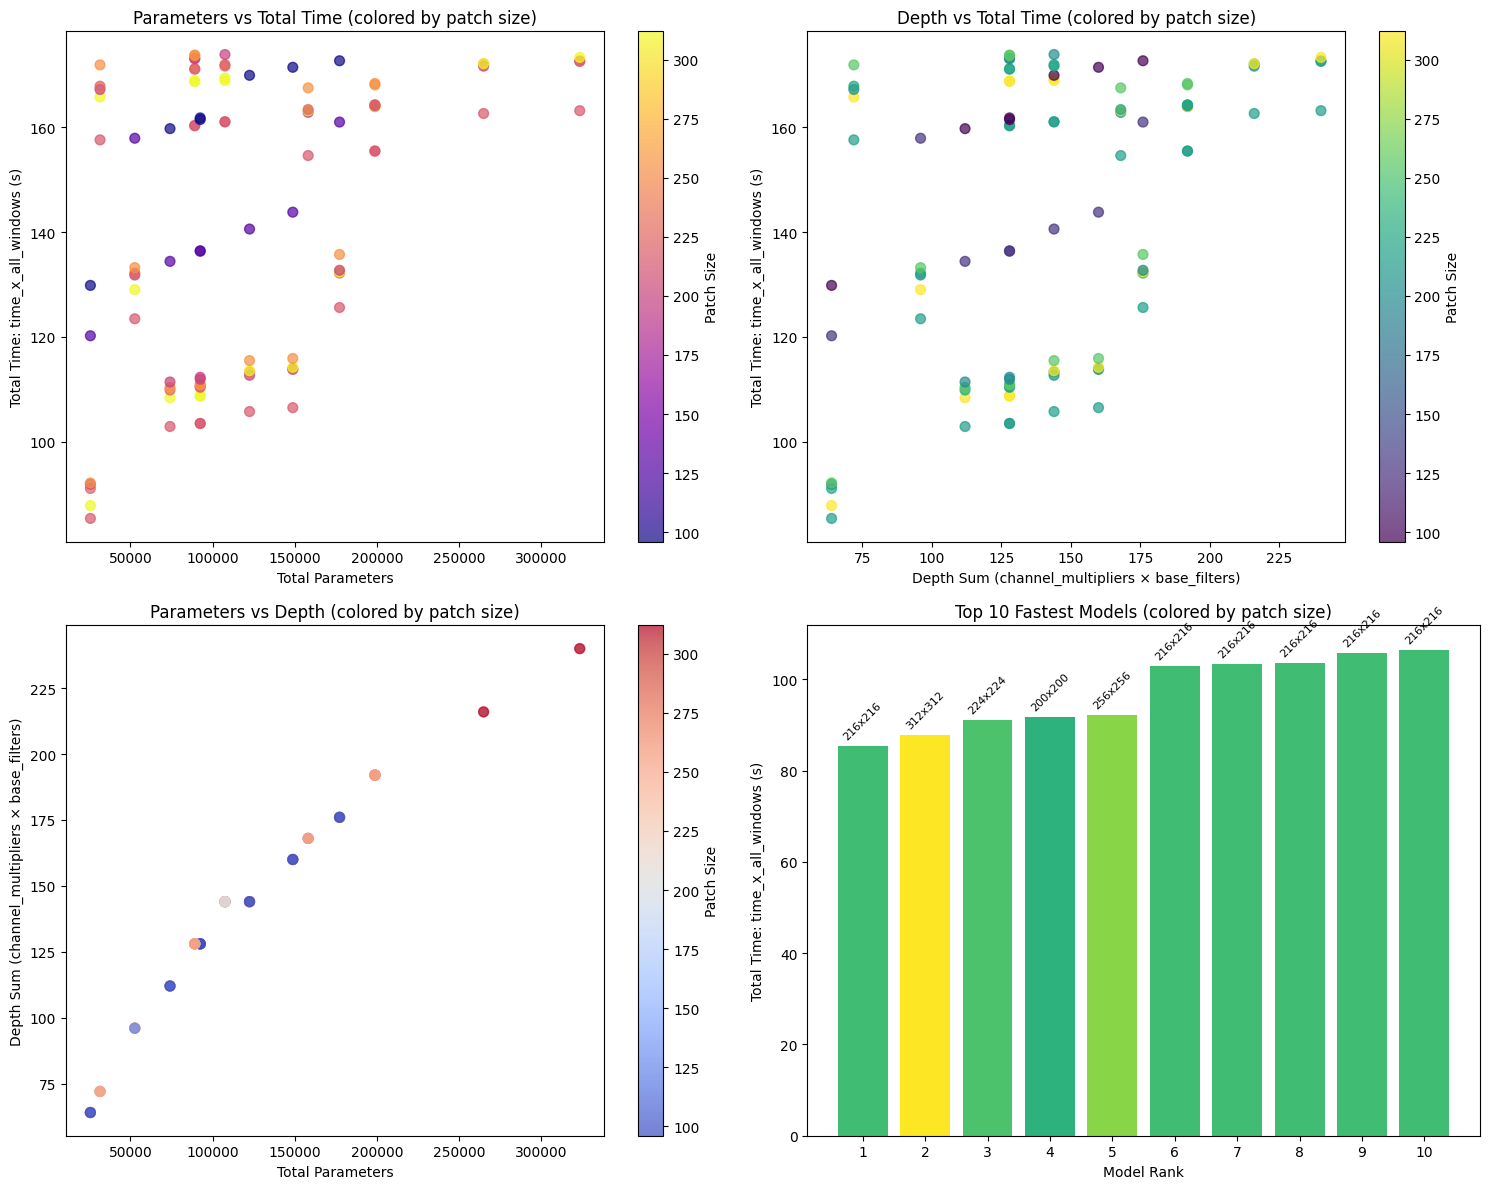


TOP 10 FASTEST MODELS DETAILED ANALYSIS (by time_x_all_windows)

Rank 1:
  Base Filters: 16
  Channel Multipliers: 1,1,1,1
  Depth List: [16, 16, 16, 16]
  Depth Sum: 64
  Total Parameters: 25,619
  Patch Size: 216x216
  Total Time (time_x_all_windows): 85.315s
  Inference Time per patch: 0.263s

Rank 2:
  Base Filters: 16
  Channel Multipliers: 1,1,1,1
  Depth List: [16, 16, 16, 16]
  Depth Sum: 64
  Total Parameters: 25,619
  Patch Size: 312x312
  Total Time (time_x_all_windows): 87.774s
  Inference Time per patch: 0.519s

Rank 3:
  Base Filters: 16
  Channel Multipliers: 1,1,1,1
  Depth List: [16, 16, 16, 16]
  Depth Sum: 64
  Total Parameters: 25,619
  Patch Size: 224x224
  Total Time (time_x_all_windows): 91.034s
  Inference Time per patch: 0.281s

Rank 4:
  Base Filters: 16
  Channel Multipliers: 1,1,1,1
  Depth List: [16, 16, 16, 16]
  Depth Sum: 64
  Total Parameters: 25,619
  Patch Size: 200x200
  Total Time (time_x_all_windows): 91.837s
  Inference Time per patch: 0.230s

Ra

In [30]:
# Create additional analysis plots using patch_size as the color marker
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Parameters vs Total Time (colored by patch_size)
scatter1 = ax1.scatter(df_best['total_parameters'], 
                      df_best['time_x_all_windows'],
                      c=df_best['patch_size'], 
                      cmap='plasma', 
                      alpha=0.7, s=50)
ax1.set_xlabel('Total Parameters')
ax1.set_ylabel('Total Time: time_x_all_windows (s)')
ax1.set_title('Parameters vs Total Time (colored by patch size)')
plt.colorbar(scatter1, ax=ax1, label='Patch Size')

# Plot 2: Depth vs Total Time (colored by patch size)
scatter2 = ax2.scatter(df_best['depth_axis_numeric'], 
                      df_best['time_x_all_windows'],
                      c=df_best['patch_size'], 
                      cmap='viridis', 
                      alpha=0.7, s=50)
ax2.set_xlabel('Depth Sum (channel_multipliers × base_filters)')
ax2.set_ylabel('Total Time: time_x_all_windows (s)')
ax2.set_title('Depth vs Total Time (colored by patch size)')
plt.colorbar(scatter2, ax=ax2, label='Patch Size')

# Plot 3: Parameters vs Depth (colored by patch size)
scatter3 = ax3.scatter(df_best['total_parameters'], 
                      df_best['depth_axis_numeric'],
                      c=df_best['patch_size'], 
                      cmap='coolwarm', 
                      alpha=0.7, s=50)
ax3.set_xlabel('Total Parameters')
ax3.set_ylabel('Depth Sum (channel_multipliers × base_filters)')
ax3.set_title('Parameters vs Depth (colored by patch size)')
plt.colorbar(scatter3, ax=ax3, label='Patch Size')

# Plot 4: Show the best 10 models details with patch size info
df_top10 = df_best.head(10)
colors = plt.cm.viridis(df_top10['patch_size'] / df_top10['patch_size'].max())
bars = ax4.bar(range(10), df_top10['time_x_all_windows'], 
               color=colors)
ax4.set_xlabel('Model Rank')
ax4.set_ylabel('Total Time: time_x_all_windows (s)')
ax4.set_title('Top 10 Fastest Models (colored by patch size)')
ax4.set_xticks(range(10))
ax4.set_xticklabels([f'{i+1}' for i in range(10)])

# Add patch size labels on bars
for i, (bar, patch_size) in enumerate(zip(bars, df_top10['patch_size'])):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{patch_size}x{patch_size}',
             ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

# Show detailed information about top 10 models
print("\n" + "="*80)
print("TOP 10 FASTEST MODELS DETAILED ANALYSIS (by time_x_all_windows)")
print("="*80)
for i, (idx, row) in enumerate(df_top10.iterrows()):
    print(f"\nRank {i+1}:")
    print(f"  Base Filters: {row['base_filters']}")
    print(f"  Channel Multipliers: {row['channel_multipliers']}")
    print(f"  Depth List: {row['depth_axis']}")
    print(f"  Depth Sum: {row['depth_axis_numeric']}")
    print(f"  Total Parameters: {row['total_parameters']:,}")
    print(f"  Patch Size: {row['patch_size']}x{row['patch_size']}")
    print(f"  Total Time (time_x_all_windows): {row['time_x_all_windows']:.3f}s")
    print(f"  Inference Time per patch: {row['inference_actual_time']:.3f}s")

# Additional analysis: Patch size distribution
print(f"\n" + "="*80)
print("PATCH SIZE DISTRIBUTION IN TOP 100 MODELS")
print("="*80)
patch_counts = df_best['patch_size'].value_counts().sort_index()
for patch_size, count in patch_counts.items():
    percentage = (count / len(df_best)) * 100
    print(f"  {patch_size}x{patch_size}: {count:2d} models ({percentage:4.1f}%)")

print(f"\nMost common patch size: {df_best['patch_size'].mode().iloc[0]}x{df_best['patch_size'].mode().iloc[0]}")
print(f"Average patch size: {df_best['patch_size'].mean():.1f}x{df_best['patch_size'].mean():.1f}")
print(f"Median patch size: {df_best['patch_size'].median():.0f}x{df_best['patch_size'].median():.0f}")

In [9]:
df.groupby('input_size').agg({
    'total_parameters': ['mean'],
    'inference_actual_time': ['mean'],
    'inference_total_time': ['mean']
})

,total_parameters,inference_actual_time,inference_total_time
,mean,mean,mean
input_size,,,
96,728201.545455,0.371962,3.001017
128,728201.545455,0.632355,3.322519
200,728201.545455,1.498611,4.378856
216,728201.545455,1.743963,4.674297
224,728201.545455,1.870952,4.825040
256,728201.545455,2.438520,5.514967
312,728201.545455,3.610255,6.937733
